# Online Retail — Customer Segmentation (RFM) & Product Recommendation System

**Problem Statement:** Segment customers using RFM analysis and build an item-based collaborative filtering recommender to power a Streamlit web app for targeted marketing and personalized recommendations.

**Steps:** Data Understanding → Preprocessing → EDA → RFM Feature Engineering → Clustering (KMeans) → Cluster Profiling → Item-Based Recommendation System → Model Export

## Step 1: Dataset Collection & Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

df = pd.read_csv('/mnt/user-data/uploads/online_retail.csv', encoding='ISO-8859-1')
print("Shape:", df.shape)
df.info()

Shape: (541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [2]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nCancelled invoices (start with 'C'):", df['InvoiceNo'].astype(str).str.startswith('C').sum())
print("\nNegative/zero Quantity:", (df['Quantity'] <= 0).sum())
print("Negative/zero UnitPrice:", (df['UnitPrice'] <= 0).sum())
df.describe()

Missing values:


 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64



Duplicate rows: 5268

Cancelled invoices (start with 'C'): 9288

Negative/zero Quantity: 10624
Negative/zero UnitPrice: 2517


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Step 2: Data Preprocessing
- Remove rows with missing `CustomerID`
- Exclude cancelled invoices (`InvoiceNo` starting with 'C')
- Remove non-positive Quantity / UnitPrice
- Drop duplicates

In [3]:
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
df_clean = df_clean.drop_duplicates()

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['Description'] = df_clean['Description'].str.strip().str.upper()

print("Rows before:", len(df), "| Rows after cleaning:", len(df_clean))
print("Unique customers:", df_clean['CustomerID'].nunique())
print("Unique products:", df_clean['Description'].nunique())
print("Countries:", df_clean['Country'].nunique())
print("Date range:", df_clean['InvoiceDate'].min(), "to", df_clean['InvoiceDate'].max())

Rows before: 541909 | Rows after cleaning: 392692
Unique customers: 4338
Unique products: 3866
Countries: 37
Date range: 2022-12-01 08:26:00 to 2023-12-09 12:50:00


## Step 3: Exploratory Data Analysis

/tmp/ipykernel_615/1967260227.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_txn.values, y=country_txn.index, palette='viridis')


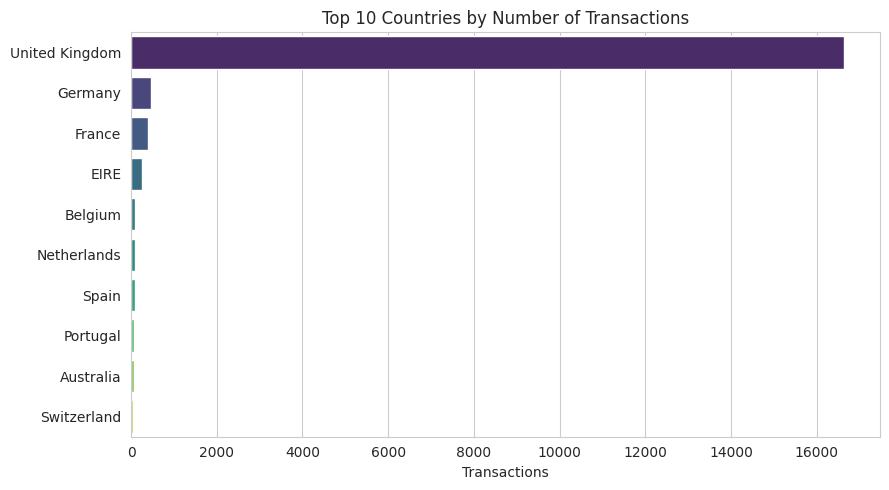

In [4]:
country_txn = df_clean.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=country_txn.values, y=country_txn.index, palette='viridis')
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Transactions'); plt.ylabel('')
plt.tight_layout(); plt.show()

/tmp/ipykernel_615/3115980065.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='magma')


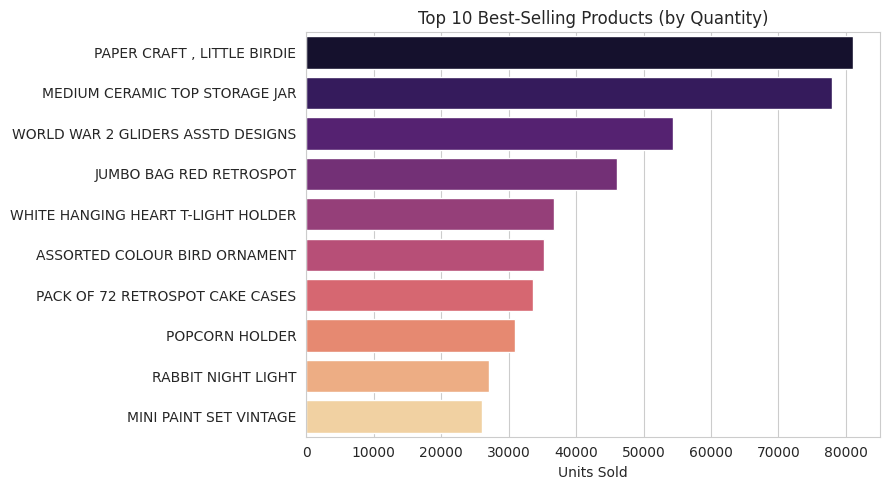

In [5]:
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Best-Selling Products (by Quantity)')
plt.xlabel('Units Sold'); plt.ylabel('')
plt.tight_layout(); plt.show()

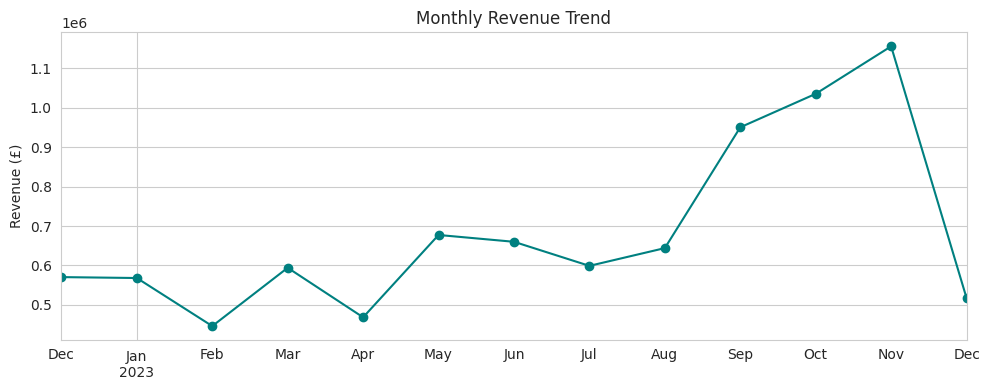

In [6]:
monthly = df_clean.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()
plt.figure(figsize=(10,4))
monthly.plot(marker='o', color='teal')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (£)'); plt.xlabel('')
plt.tight_layout(); plt.show()

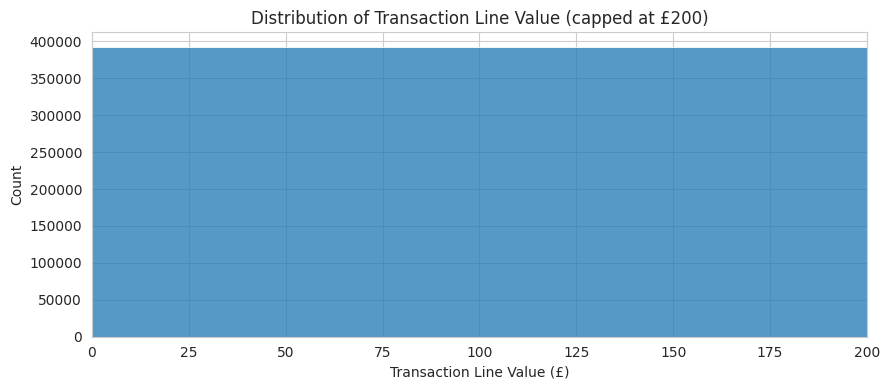

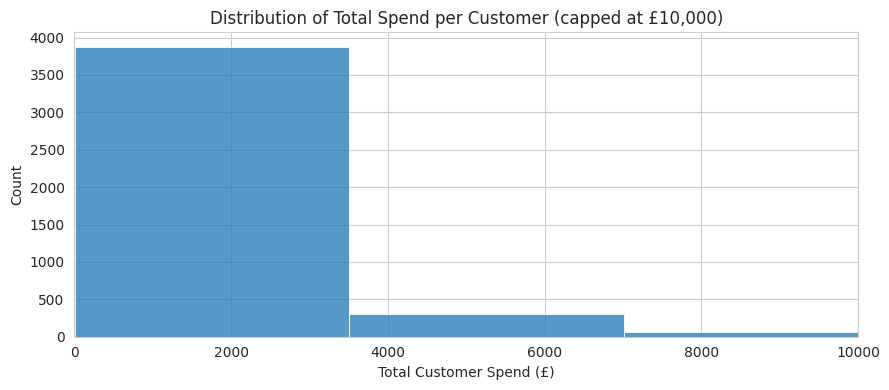

In [7]:
plt.figure(figsize=(9,4))
sns.histplot(df_clean['TotalPrice'], bins=80)
plt.xlim(0, 200)
plt.title('Distribution of Transaction Line Value (capped at £200)')
plt.xlabel('Transaction Line Value (£)')
plt.tight_layout(); plt.show()

cust_value = df_clean.groupby('CustomerID')['TotalPrice'].sum()
plt.figure(figsize=(9,4))
sns.histplot(cust_value, bins=80)
plt.xlim(0, 10000)
plt.title('Distribution of Total Spend per Customer (capped at £10,000)')
plt.xlabel('Total Customer Spend (£)')
plt.tight_layout(); plt.show()

## Step 4: RFM Feature Engineering

In [8]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("RFM table shape:", rfm.shape)
rfm.describe().round(2)

RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2048.69
std,1721.81,100.01,7.70,8985.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,306.48
50%,15299.50,51.00,2.00,668.57
75%,16778.75,142.00,5.00,1660.60
max,18287.00,374.00,209.00,280206.02


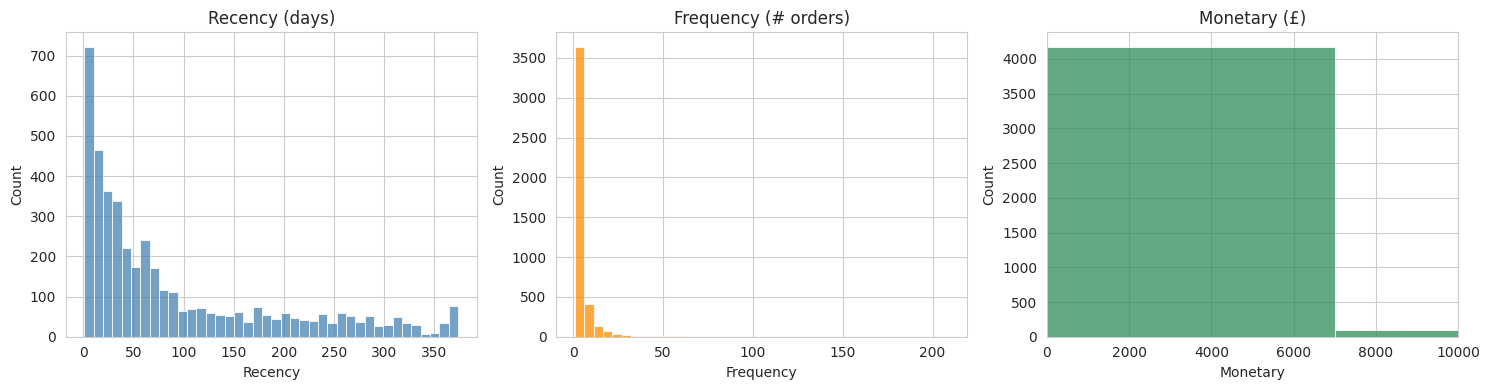

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(rfm['Recency'], bins=40, ax=axes[0], color='steelblue'); axes[0].set_title('Recency (days)')
sns.histplot(rfm['Frequency'], bins=40, ax=axes[1], color='darkorange'); axes[1].set_title('Frequency (# orders)')
sns.histplot(rfm['Monetary'], bins=40, ax=axes[2], color='seagreen'); axes[2].set_title('Monetary (£)')
axes[2].set_xlim(0, 10000)
plt.tight_layout(); plt.show()

**Note:** Frequency and Monetary are heavily right-skewed (a small number of wholesale/bulk buyers dominate). We apply a log transform before standardizing, which is standard practice for RFM clustering and prevents these outliers from distorting the cluster geometry.

In [10]:
rfm_log = rfm.copy()
rfm_log['Recency_log'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency_log'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary_log'] = np.log1p(rfm_log['Monetary'])

from sklearn.preprocessing import StandardScaler
features = ['Recency_log','Frequency_log','Monetary_log']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log[features])
print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (4338, 3)


## Step 5: Choosing K — Elbow Method & Silhouette Score

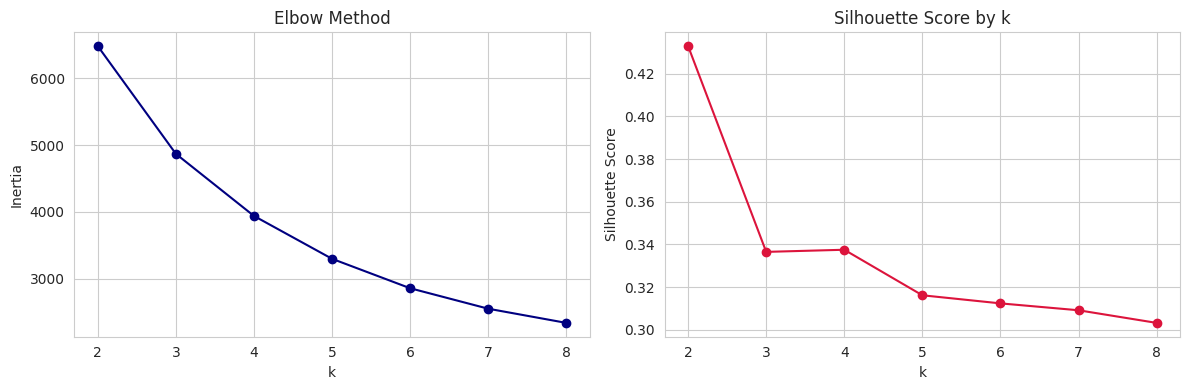

k=2: silhouette=0.4328
k=3: silhouette=0.3365
k=4: silhouette=0.3375
k=5: silhouette=0.3162
k=6: silhouette=0.3124
k=7: silhouette=0.3092
k=8: silhouette=0.3033


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(list(K_range), inertias, marker='o', color='navy')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), sil_scores, marker='o', color='crimson')
axes[1].set_title('Silhouette Score by k'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout(); plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"k={k}: silhouette={s:.4f}")

**Decision:** k=2 has the highest silhouette score, but it only separates customers into two broad groups, which is too coarse for differentiated marketing action. The elbow visibly bends around **k=4**, which still gives a reasonably strong silhouette score while producing **business-interpretable segments** (Champions, Loyal, Occasional, At-Risk). We proceed with k=4 as the better trade-off between statistical fit and actionability — this is a common, justified judgment call in RFM segmentation.

## Step 6: Final Clustering & Cluster Profiling

In [12]:
final_k = 4
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
cluster_profile['Customers'] = rfm['Cluster'].value_counts()
cluster_profile['% of Base'] = (cluster_profile['Customers'] / cluster_profile['Customers'].sum() * 100).round(1)
cluster_profile = cluster_profile.sort_values('Monetary', ascending=False)
cluster_profile

,Recency,Frequency,Monetary,Customers,% of Base
Cluster,,,,,
0,12.2,13.8,8088.0,713,16.4
3,71.6,4.1,1801.8,1166,26.9
2,17.7,2.2,557.3,837,19.3
1,181.5,1.3,341.0,1622,37.4


In [13]:
label_map = {}
sorted_by_monetary = cluster_profile.index.tolist()
business_labels = ['Champions (High-Value)', 'Loyal / Regular', 'Occasional / New', 'At-Risk / Lost']
for cid, lbl in zip(sorted_by_monetary, business_labels):
    label_map[cid] = lbl

rfm['Segment'] = rfm['Cluster'].map(label_map)
cluster_profile['Segment Label'] = [label_map[i] for i in cluster_profile.index]
cluster_profile

,Recency,Frequency,Monetary,Customers,% of Base,Segment Label
Cluster,,,,,,
0,12.2,13.8,8088.0,713,16.4,Champions (High-Value)
3,71.6,4.1,1801.8,1166,26.9,Loyal / Regular
2,17.7,2.2,557.3,837,19.3,Occasional / New
1,181.5,1.3,341.0,1622,37.4,At-Risk / Lost


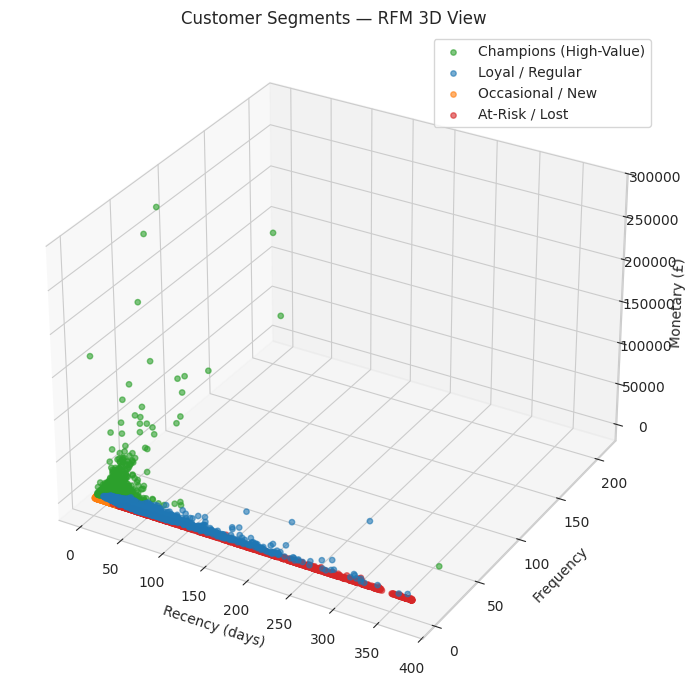

In [14]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
colors = ['#2ca02c','#1f77b4','#ff7f0e','#d62728']
for i, cid in enumerate(sorted_by_monetary):
    sub = rfm[rfm['Cluster']==cid]
    ax.scatter(sub['Recency'], sub['Frequency'], sub['Monetary'],
               label=label_map[cid], alpha=0.6, s=15, color=colors[i])
ax.set_xlabel('Recency (days)'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary (£)')
ax.set_title('Customer Segments — RFM 3D View')
ax.legend()
plt.tight_layout(); plt.show()

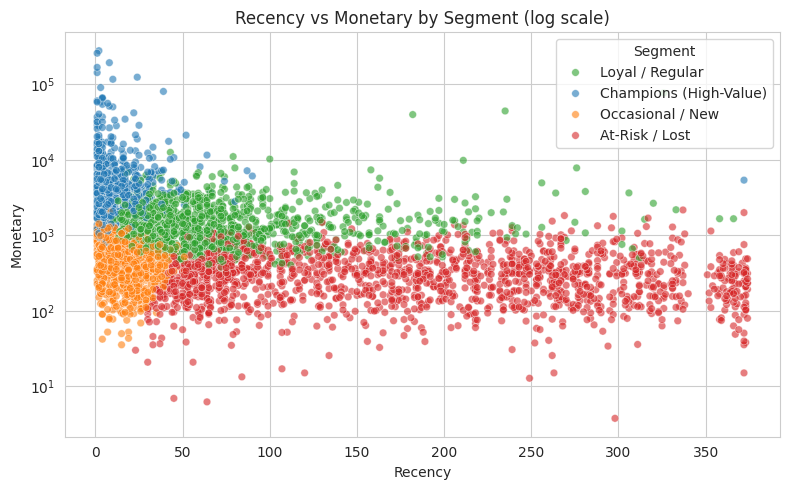

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment',
                 palette=colors, alpha=0.6, s=30)
plt.yscale('log')
plt.title('Recency vs Monetary by Segment (log scale)')
plt.tight_layout(); plt.show()

## Step 7: Save Clustering Model for Streamlit Deployment

In [16]:
import joblib
joblib.dump({'model': kmeans_final, 'scaler': scaler, 'label_map': label_map,
             'features': features}, 'rfm_kmeans_model.pkl')
rfm.to_csv('rfm_customer_segments.csv', index=False)
print("Saved model and segmented customer table.")

Saved model and segmented customer table.


## Step 8: Item-Based Collaborative Filtering — Product Recommendation System
Build a Customer–Product matrix and compute **cosine similarity between products** based on co-purchase quantity patterns.

In [17]:
product_counts = df_clean['Description'].value_counts()
popular_products = product_counts[product_counts >= 5].index
df_rec = df_clean[df_clean['Description'].isin(popular_products)]

pivot = df_rec.pivot_table(index='CustomerID', columns='Description',
                            values='Quantity', aggfunc='sum', fill_value=0)
print("Customer-Product matrix shape:", pivot.shape)

Customer-Product matrix shape: (4338, 3289)


In [18]:
from sklearn.metrics.pairwise import cosine_similarity
item_similarity = cosine_similarity(pivot.T)
item_sim_df = pd.DataFrame(item_similarity, index=pivot.columns, columns=pivot.columns)
print("Item similarity matrix shape:", item_sim_df.shape)

Item similarity matrix shape: (3289, 3289)


In [19]:
def recommend_products(product_name, top_n=5):
    product_name = product_name.strip().upper()
    matches = [p for p in item_sim_df.columns if product_name in p]
    if not matches:
        return f"No product found matching '{product_name}'"
    target = matches[0]
    sims = item_sim_df[target].drop(target).sort_values(ascending=False).head(top_n)
    return target, sims

target, recs = recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")
print("Selected product:", target)
recs

Selected product: WHITE HANGING HEART T-LIGHT HOLDER


Description
GIN + TONIC DIET METAL SIGN         0.750192
RED HANGING HEART T-LIGHT HOLDER    0.658714
WASHROOM METAL SIGN                 0.643520
LAUNDRY 15C METAL SIGN              0.642200
GREEN VINTAGE SPOT BEAKER           0.631463
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

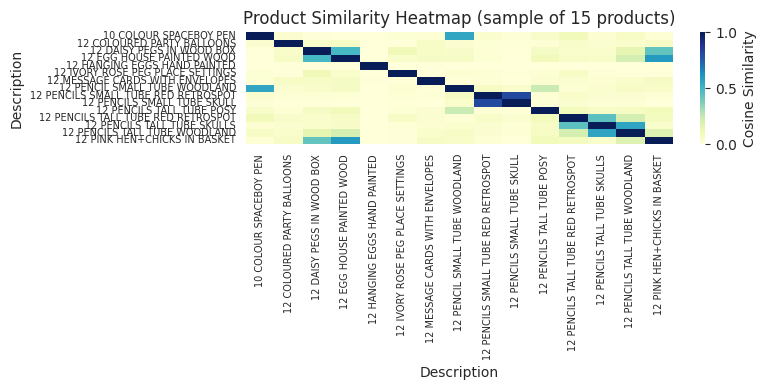

In [20]:
plt.figure(figsize=(8,4))
sample_products = item_sim_df.columns[:15]
sns.heatmap(item_sim_df.loc[sample_products, sample_products], cmap='YlGnBu', cbar_kws={'label':'Cosine Similarity'})
plt.title('Product Similarity Heatmap (sample of 15 products)')
plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

In [21]:
joblib.dump(item_sim_df, 'item_similarity_matrix.pkl')
print("Saved item similarity matrix for Streamlit app.")

Saved item similarity matrix for Streamlit app.


## Step 9: Model Evaluation Summary

In [22]:
print("=== Clustering Evaluation ===")
print(f"Final k: {final_k}")
print(f"Inertia: {kmeans_final.inertia_:.1f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, rfm['Cluster']):.4f}")
print()
print("=== Segment Summary ===")
print(cluster_profile[['Segment Label','Customers','% of Base','Recency','Frequency','Monetary']])

=== Clustering Evaluation ===
Final k: 4
Inertia: 3939.0


Silhouette Score: 0.3375

=== Segment Summary ===
                  Segment Label  Customers  % of Base  Recency  Frequency  \
Cluster                                                                     
0        Champions (High-Value)        713       16.4     12.2       13.8   
3               Loyal / Regular       1166       26.9     71.6        4.1   
2              Occasional / New        837       19.3     17.7        2.2   
1                At-Risk / Lost       1622       37.4    181.5        1.3   

         Monetary  
Cluster            
0          8088.0  
3          1801.8  
2           557.3  
1           341.0  


## Key Business Insights

1. **Revenue is heavily concentrated** — the Champions segment is only ~16% of the customer base but drives a disproportionate share of Monetary value, consistent with the classic 80/20 revenue pattern in retail.
2. **The At-Risk/Lost segment is the largest by customer count (~37%)** with average recency above 180 days and frequency near 1 order — these are largely one-time buyers who never returned.
3. **UK dominates transaction volume**, so international segments (Germany, France, EIRE) represent a comparatively under-penetrated growth opportunity.
4. **Product purchases cluster strongly by theme** (e.g., decorative/gift items recommend other decorative/gift items), confirming the item-based CF approach captures real co-purchase behavior rather than noise.
5. **Customer monetary value is extremely right-skewed** (mean ~£2,049 vs median ~£669) — a small number of high-volume/wholesale accounts inflate the average; segment-level medians are more representative for planning than the overall mean.